# Multiaxial spectral fatigue criteria in FLife

Every multiaxial equivalent-stress criterion in FLife is applied to the same
stress cross-PSD, so differences come only from the criterion. The criteria are
compared by their equivalent stress; the fatigue life (reference axial S-N curve
with Tovo-Benasciutti, method 2) is reported in the tables as a downstream
consequence.

Two stress cross-PSD inputs (in `data/`), both from the finite-element
vibration-fatigue study of Mrsnik, Slavic and Boltezar (2016), AlSi7Cu3:

1. `comparison_PSD_near_uniaxial.npy` -- normal-stress-dominated (df = 0.5 Hz).
2. `comparison_PSD_multiaxial.npy` -- combined bending and torsion, from two
   independent modal sources (df = 1.0 Hz).

Requires the critical-plane fix from ladisk/FLife PR #27; without it the three
critical-plane criteria return the same value.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import FLife

print("FLife", FLife.__version__)

FLife 2.1.0


## Material and S-N curve

AlSi7Cu3 fatigue limits and reference axial S-N curve (Mrsnik et al. 2016). The
Basquin fit `S = sf*(2N)**b` is converted to the FLife form `N*S**k = C`
(`k = -1/b`, `C = 0.5*sf**k`), and used for every criterion.

In [2]:
S_AF, TAU_AF, POISSON = 161.0, 97.0, 0.33   # MPa, MPa, -

BASQUIN_B, BASQUIN_SF = -0.179517, 1360.46
K = -1.0 / BASQUIN_B
C = 0.5 * BASQUIN_SF ** K

# Loading level. The stored PSDs are arbitrarily scaled, so to report a
# meaningful absolute life we scale each case so its EVMS RMS equivalent stress
# equals this value (a representative level below the s_af = 161 MPa limit).
TARGET_EVMS_RMS = 60.0   # MPa

print(f"k = {K:.4f}, C = {C:.4e} MPa^k")

k = 5.5705, C = 1.4295e+17 MPa^k


## Helpers

`load_psd` reads a cross-PSD and builds its frequency vector; `plane_stress_layouts`
returns the (f,6,6) and (f,3,3) layouts the criteria require; `run_all` evaluates
the ten criteria; `at_load_level` rescales the results to a stated EVMS RMS.

In [3]:
def load_psd(path, df):
    """Load a (f,6,6) stress cross-PSD .npy and build its frequency vector."""
    psd = np.load(path)
    f = np.arange(psd.shape[0]) * df
    return psd, f


def plane_stress_layouts(psd6_full):
    """Surface components are sxx (0), syy (1), txy (3) of (sxx,syy,szz,txy,txz,tyz)."""
    surf = [0, 1, 3]
    psd3 = psd6_full[:, surf][:, :, surf]
    psd6 = np.zeros_like(psd6_full)
    for ii, a in enumerate(surf):
        for jj, b in enumerate(surf):
            psd6[:, a, b] = psd3[:, ii, jj]
    return psd6, psd3


def run_all(psd6, psd3, f):
    criteria = [
        ("max_normal",           lambda e: e.max_normal(),                                            psd6),
        ("max_shear",            lambda e: e.max_shear(),                                             psd6),
        ("max_normal_and_shear", lambda e: e.max_normal_and_shear(s_af=S_AF, tau_af=TAU_AF),          psd6),
        ("EVMS",                 lambda e: e.EVMS(),                                                  psd6),
        ("cs",                   lambda e: e.cs(s_af=S_AF, tau_af=TAU_AF),                            psd6),
        ("multiaxial_rainflow",  lambda e: e.multiaxial_rainflow(),                                   psd3),
        ("thermoelastic",        lambda e: e.thermoelastic(),                                         psd6),
        ("EVMS_out_of_phase",    lambda e: e.EVMS_out_of_phase(),                                     psd3),
        ("Nieslony",             lambda e: e.Nieslony(s_af=S_AF, tau_af=TAU_AF, coefficient_load_type="tension"), psd6),
        ("Lemaitre",             lambda e: e.Lemaitre(poisson_ratio=POISSON),                         psd6),
    ]
    rows, eq = [], {}
    for name, call, psd in criteria:
        es = FLife.EquivalentStress(input={"PSD": psd, "f": f})
        call(es)
        eq[name] = np.real(es.psd[:, 1]).copy()
        m0 = float(np.real(es.moments[0]))
        life = float(np.real(FLife.TovoBenasciutti(es).get_life(C, K, method="method 2")))
        rows.append({"criterion": name, "m0": m0, "life": life})
    evms = next(r["life"] for r in rows if r["criterion"] == "EVMS")
    for r in rows:
        r["ratio_to_EVMS"] = r["life"] / evms
    return rows, eq


def at_load_level(rows, eq, psd6, target_rms):
    """Rescale the results to a stated EVMS RMS equivalent stress [MPa].

    The criteria are evaluated at the data's own (arbitrary) scale and the
    results are then scaled deterministically: with a stress factor alpha,
    m0 -> alpha*m0 and life -> alpha**(-k/2)*life. This keeps the optimiser
    inputs at their validated scale (so the ratios are exact) while reporting a
    meaningful absolute life. Returns the rescaled (rows, eq, psd6).
    """
    m0_evms = next(r["m0"] for r in rows if r["criterion"] == "EVMS")
    alpha = target_rms ** 2 / m0_evms
    for r in rows:
        r["m0"] *= alpha
        r["life"] *= alpha ** (-K / 2)
    eq = {name: ps * alpha for name, ps in eq.items()}
    return rows, eq, psd6 * alpha


def human_time(seconds):
    """Format a duration in the largest sensible unit."""
    for unit, length in (("yr", 31_557_600.0), ("d", 86_400.0),
                         ("h", 3_600.0), ("min", 60.0)):
        if seconds >= length:
            return f"{seconds / length:.1f} {unit}"
    return f"{seconds:.0f} s"


def show(rows, title):
    print(title)
    print(f"{'criterion':22s}{'m0 [MPa^2]':>15s}{'life [s]':>15s}{'life/EVMS':>12s}")
    for r in rows:
        print(f"{r['criterion']:22s}{r['m0']:15.4e}{r['life']:15.4e}{r['ratio_to_EVMS']:12.3f}")

## Case 1 -- near-uniaxial

Normal-stress-dominated state (sigma_xx dominant, a small in-phase sigma_yy, no
shear). The max-normal and max-shear planes nearly coincide, so the three
critical-plane criteria give close results.

In [4]:
psd_a, f_a = load_psd("data/comparison_PSD_near_uniaxial.npy", df=0.5)
psd6_a, psd3_a = plane_stress_layouts(psd_a)
rows_a, eq_a = run_all(psd6_a, psd3_a, f_a)
rows_a, eq_a, psd6_a = at_load_level(rows_a, eq_a, psd6_a, TARGET_EVMS_RMS)
show(rows_a, "Case 1 -- near-uniaxial")

Case 1 -- near-uniaxial
criterion                  m0 [MPa^2]       life [s]   life/EVMS
max_normal                 4.7042e+03     5.0364e+03       0.475
max_shear                  4.7042e+03     5.0364e+03       0.475
max_normal_and_shear       4.7042e+03     5.0364e+03       0.475
EVMS                       3.6000e+03     1.0609e+04       1.000
cs                         3.1280e+03     1.5711e+04       1.481
multiaxial_rainflow        5.3631e+03     3.5189e+03       0.332
thermoelastic              8.9125e+03     8.4967e+02       0.080
EVMS_out_of_phase          3.6000e+03     1.0609e+04       1.000
Nieslony                   3.7743e+03     9.3000e+03       0.877
Lemaitre                   4.2021e+03     6.8966e+03       0.650


## Case 2 -- combined bending and torsion

Node 16467, rebuilt from two independent modal sources: a near-pure-shear
(torsion) mode and a near-equibiaxial-normal (bending) mode. Modal frequencies,
damping and relative magnitudes are illustrative. Shear is present, so the
critical-plane criteria separate.

In [5]:
psd_b, f_b = load_psd("data/comparison_PSD_multiaxial.npy", df=1.0)
psd6_b, psd3_b = plane_stress_layouts(psd_b)
rows_b, eq_b = run_all(psd6_b, psd3_b, f_b)
rows_b, eq_b, psd6_b = at_load_level(rows_b, eq_b, psd6_b, TARGET_EVMS_RMS)
show(rows_b, "Case 2 -- combined bending and torsion")

Case 2 -- combined bending and torsion
criterion                  m0 [MPa^2]       life [s]   life/EVMS
max_normal                 1.9911e+03     7.4876e+03       5.732
max_shear                  4.2342e+03     7.9654e+02       0.610
max_normal_and_shear       3.2513e+03     1.7162e+03       1.314
EVMS                       3.6000e+03     1.3063e+03       1.000
cs                         2.1290e+03     5.7616e+03       4.411
multiaxial_rainflow        1.8790e+03     8.8386e+03       6.766
thermoelastic              1.6965e+03     1.3067e+04      10.003
EVMS_out_of_phase          3.5994e+03     1.3070e+03       1.001
Nieslony                   3.4139e+03     1.5271e+03       1.169
Lemaitre                   3.3843e+03     1.5786e+03       1.208


## Stress PSD and equivalent PSDs

Each criterion reduces the stress cross-PSD to one equivalent-stress PSD. Left:
the input, as its diagonal stress-PSD components. Right: the equivalent-stress
PSD from each criterion.

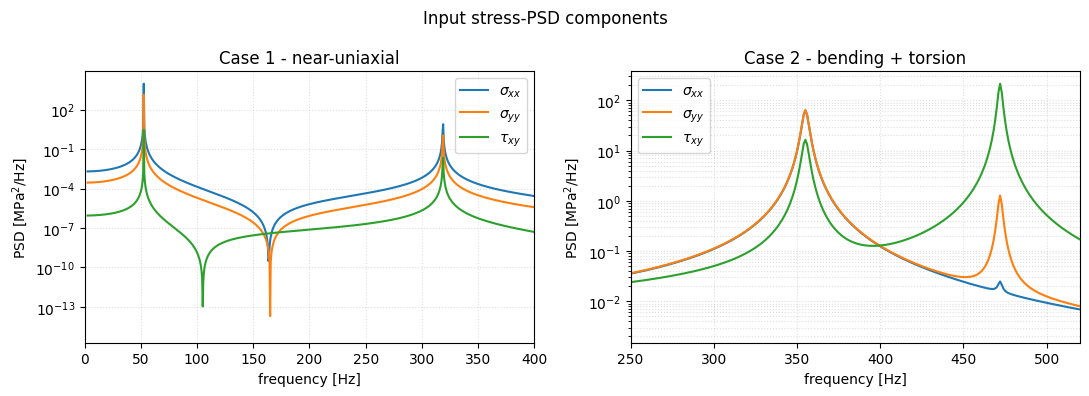

In [6]:
def _pos(a):
    """Keep positive values for a log plot, mask the rest."""
    a = np.real(a)
    return np.where(a > 0, a, np.nan)

# input stress-PSD components (auto-spectra of sxx, syy, txy)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cases = [(psd6_a, f_a, "Case 1 - near-uniaxial", (0, 400)),
         (psd6_b, f_b, "Case 2 - bending + torsion", (250, 520))]
for ax, (psd, f, title, xlim) in zip(axes, cases):
    ax.semilogy(f, _pos(psd[:, 0, 0]), label=r"$\sigma_{xx}$")
    ax.semilogy(f, _pos(psd[:, 1, 1]), label=r"$\sigma_{yy}$")
    ax.semilogy(f, _pos(psd[:, 3, 3]), label=r"$\tau_{xy}$")
    ax.set_title(title)
    ax.set_xlabel("frequency [Hz]")
    ax.set_ylabel(r"PSD [MPa$^2$/Hz]")
    ax.set_xlim(*xlim)
    ax.legend()
    ax.grid(True, which="both", ls=":", alpha=0.4)
fig.suptitle("Input stress-PSD components")
fig.tight_layout()
plt.show()

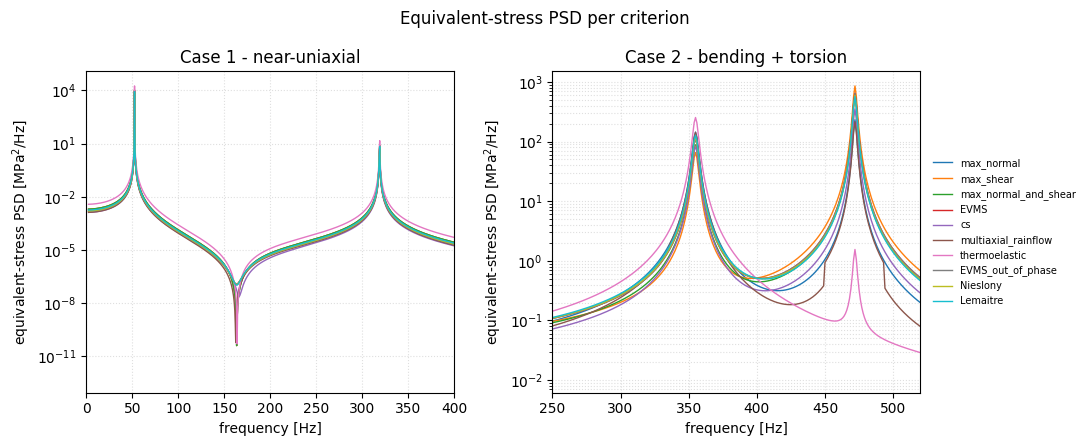

In [7]:
# equivalent-stress PSD from each criterion (the "after" of each criterion)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
eq_cases = [(eq_a, f_a, "Case 1 - near-uniaxial", (0, 400)),
            (eq_b, f_b, "Case 2 - bending + torsion", (250, 520))]
for ax, (eq, f, title, xlim) in zip(axes, eq_cases):
    for name, ps in eq.items():
        ax.semilogy(f, _pos(ps), lw=1.0, label=name)
    ax.set_title(title)
    ax.set_xlabel("frequency [Hz]")
    ax.set_ylabel(r"equivalent-stress PSD [MPa$^2$/Hz]")
    ax.set_xlim(*xlim)
    ax.grid(True, which="both", ls=":", alpha=0.4)
axes[1].legend(fontsize=7, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("Equivalent-stress PSD per criterion")
fig.tight_layout()
plt.show()

## Equivalent-stress comparison

RMS of each criterion's equivalent-stress process (sqrt of m0), at equal loading
(EVMS RMS = `TARGET_EVMS_RMS`; dashed line). The spread across the ten criteria
is about 1.7x. The predicted lives (tables above) spread about 18x, because life
scales as stress^-k with k = 5.6.

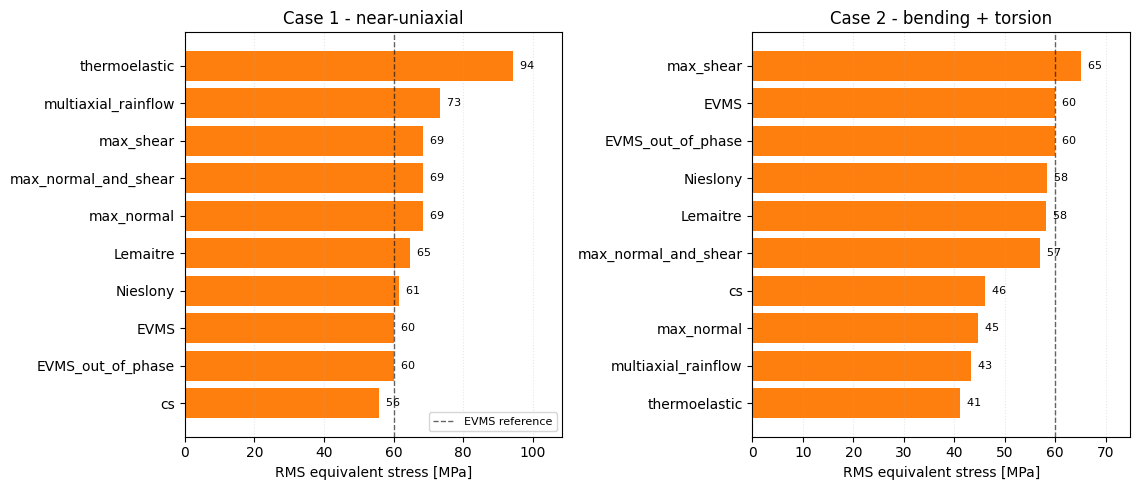

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5))
for ax, rows, title in zip(axes, [rows_a, rows_b],
                           ["Case 1 - near-uniaxial", "Case 2 - bending + torsion"]):
    srt = sorted(rows, key=lambda r: r["m0"], reverse=True)   # most severe on top
    labels = [r["criterion"] for r in srt]
    rms = np.array([r["m0"] ** 0.5 for r in srt])
    yy = np.arange(len(labels))

    ax.barh(yy, rms, color="tab:orange")
    for i, v in enumerate(rms):
        ax.text(v, yy[i], f"  {v:.0f}", va="center", ha="left", fontsize=8)
    ax.axvline(TARGET_EVMS_RMS, color="k", lw=1.0, ls="--", alpha=0.6,
               label="EVMS reference")

    ax.set_xlim(0, rms.max() * 1.15)
    ax.set_yticks(yy)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("RMS equivalent stress [MPa]")
    ax.set_title(title)
    ax.grid(True, axis="x", ls=":", alpha=0.3)
axes[0].legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

## Summary

Criterion choice changes the equivalent stress by about 1.7x (and the life by
about 18x) on identical data. The three critical-plane criteria coincide in
Case 1 and separate in Case 2, where max-shear is the most conservative. EVMS equals EVMS-out-of-phase because both
inputs are proportional at each frequency.